#HW №3 Анисимов Андрей Дмитриевич РИ-421003

##Данные

###Визуализируйте ряд, пометив аномальные точки

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
# Загрузка данных
df = pd.read_csv('/content/skab_valve_1.csv', delimiter=';', parse_dates=['datetime'])
df

,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
0,2020-03-09 12:34:37,0.028030,0.040400,1.182850,0.054711,69.9219,24.9122,229.918,32.9875,0.0,0.0
1,2020-03-09 12:34:38,0.026952,0.038880,1.452680,-0.273216,69.9147,24.9038,219.566,32.0129,0.0,0.0
2,2020-03-09 12:34:39,0.027958,0.040660,1.023000,0.054711,69.8861,24.9055,237.717,32.9875,0.0,0.0
3,2020-03-09 12:34:40,0.027277,0.040736,1.227510,-0.273216,69.8397,24.9110,227.621,32.0000,0.0,0.0
4,2020-03-09 12:34:41,0.027210,0.039489,1.215260,-0.273216,69.9136,24.9110,221.634,32.0129,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1089,2020-03-09 12:54:33,0.027358,0.041076,0.646547,0.054711,70.1018,24.8565,241.861,32.0000,0.0,0.0
1090,2020-03-09 12:54:34,0.027187,0.039463,0.672100,0.382638,70.0783,24.8596,246.590,32.0000,0.0,0.0
1091,2020-03-09 12:54:35,0.027795,0.040085,0.596467,0.054711,70.0489,24.8600,232.107,32.0000,0.0,0.0
1092,2020-03-09 12:54:36,0.026888,0.039586,0.914037,0.382638,70.1022,24.8553,253.688,31.0151,0.0,0.0


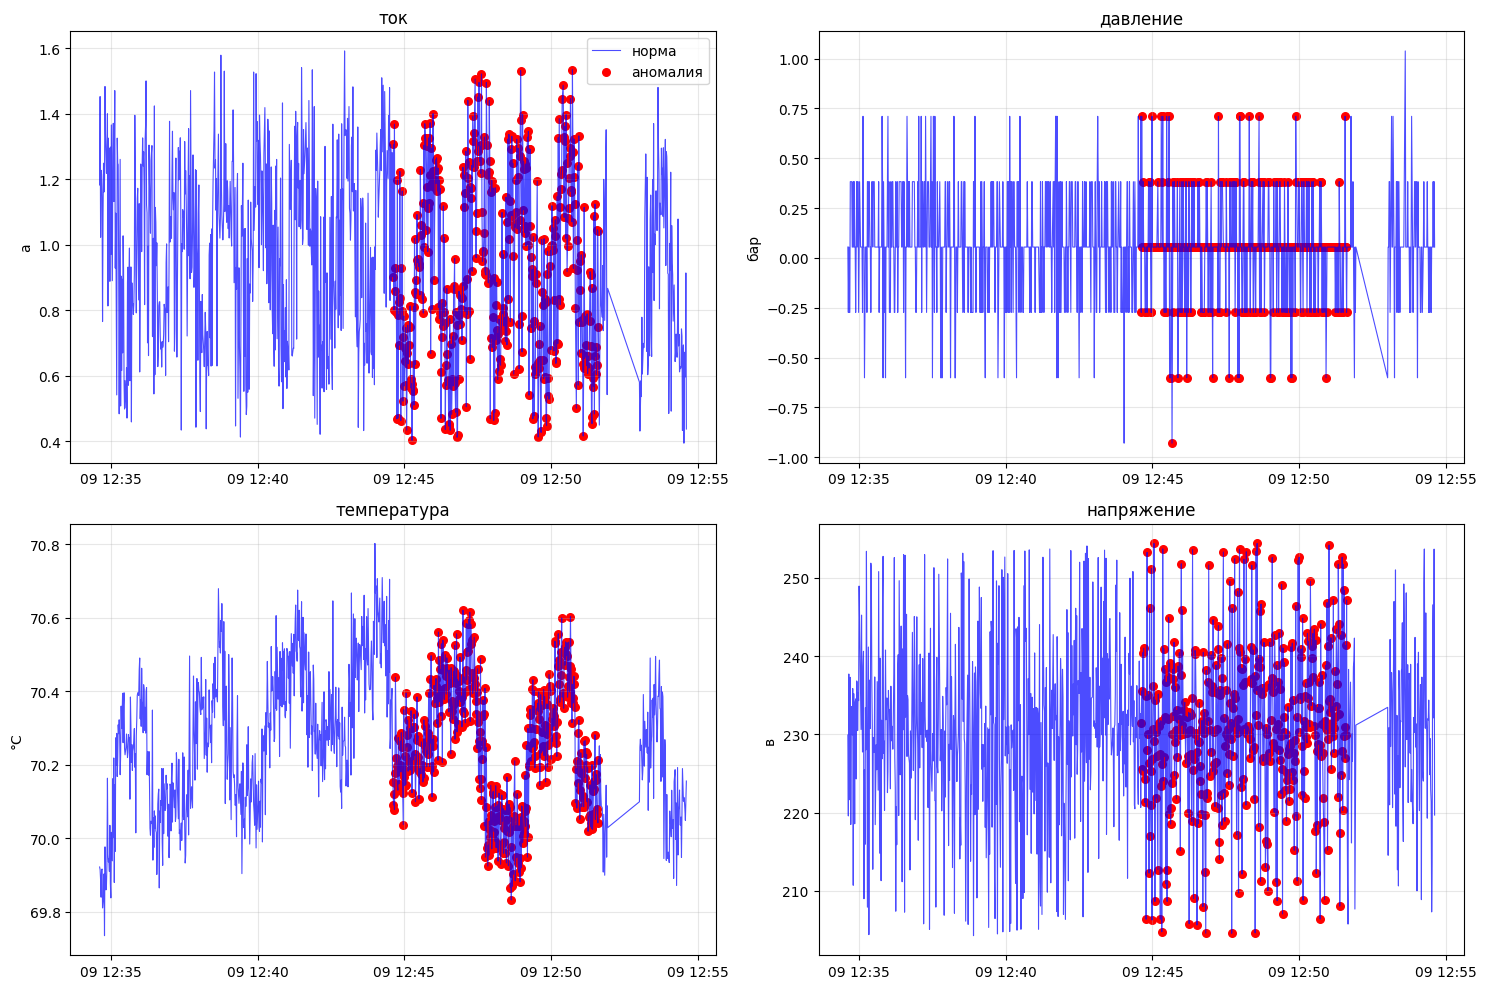

In [3]:
# Создание фигуры и осей
plt.figure(figsize=(15, 10))

anomalies = df[df['anomaly'] == 1]

plt.subplot(2, 2, 1)
plt.plot(df['datetime'], df['Current'], 'b-', alpha=0.7, linewidth=0.8, label='норма')
if not anomalies.empty:
    plt.scatter(anomalies['datetime'], anomalies['Current'],
                color='red', s=30, label='аномалия')
plt.title('ток')
plt.ylabel('а')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(df['datetime'], df['Pressure'], 'b-', alpha=0.7, linewidth=0.8)
if not anomalies.empty:
    plt.scatter(anomalies['datetime'], anomalies['Pressure'], color='red', s=30)
plt.title('давление')
plt.ylabel('бар')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(df['datetime'], df['Temperature'], 'b-', alpha=0.7, linewidth=0.8)
if not anomalies.empty:
    plt.scatter(anomalies['datetime'], anomalies['Temperature'], color='red', s=30)
plt.title('температура')
plt.ylabel('°C')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(df['datetime'], df['Voltage'], 'b-', alpha=0.7, linewidth=0.8)
if not anomalies.empty:
    plt.scatter(anomalies['datetime'], anomalies['Voltage'], color='red', s=30)
plt.title('напряжение')
plt.ylabel('в')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##Поиск аномалий

###Статистические эвристики

####Реализуйте фильтрацию аномалий на основе расчитанных статистик [Q1 - (1.5 * IQR), Q3 + (1.5 * IQR)], [Q1 - (3 * IQR), Q3 + (3 * IQR)]

Current: IQR 1.5 границы [0.0015, 1.9119], IQR 3 границы [-0.7148, 2.6282]
Pressure: IQR 1.5 границы [-0.3142, 0.6696], IQR 3 границы [-0.6831, 1.0385]
Temperature: IQR 1.5 границы [69.6998, 70.8119], IQR 3 границы [69.2828, 71.2289]
Voltage: IQR 1.5 границы [206.8896, 255.3786], IQR 3 границы [188.7062, 273.5620]


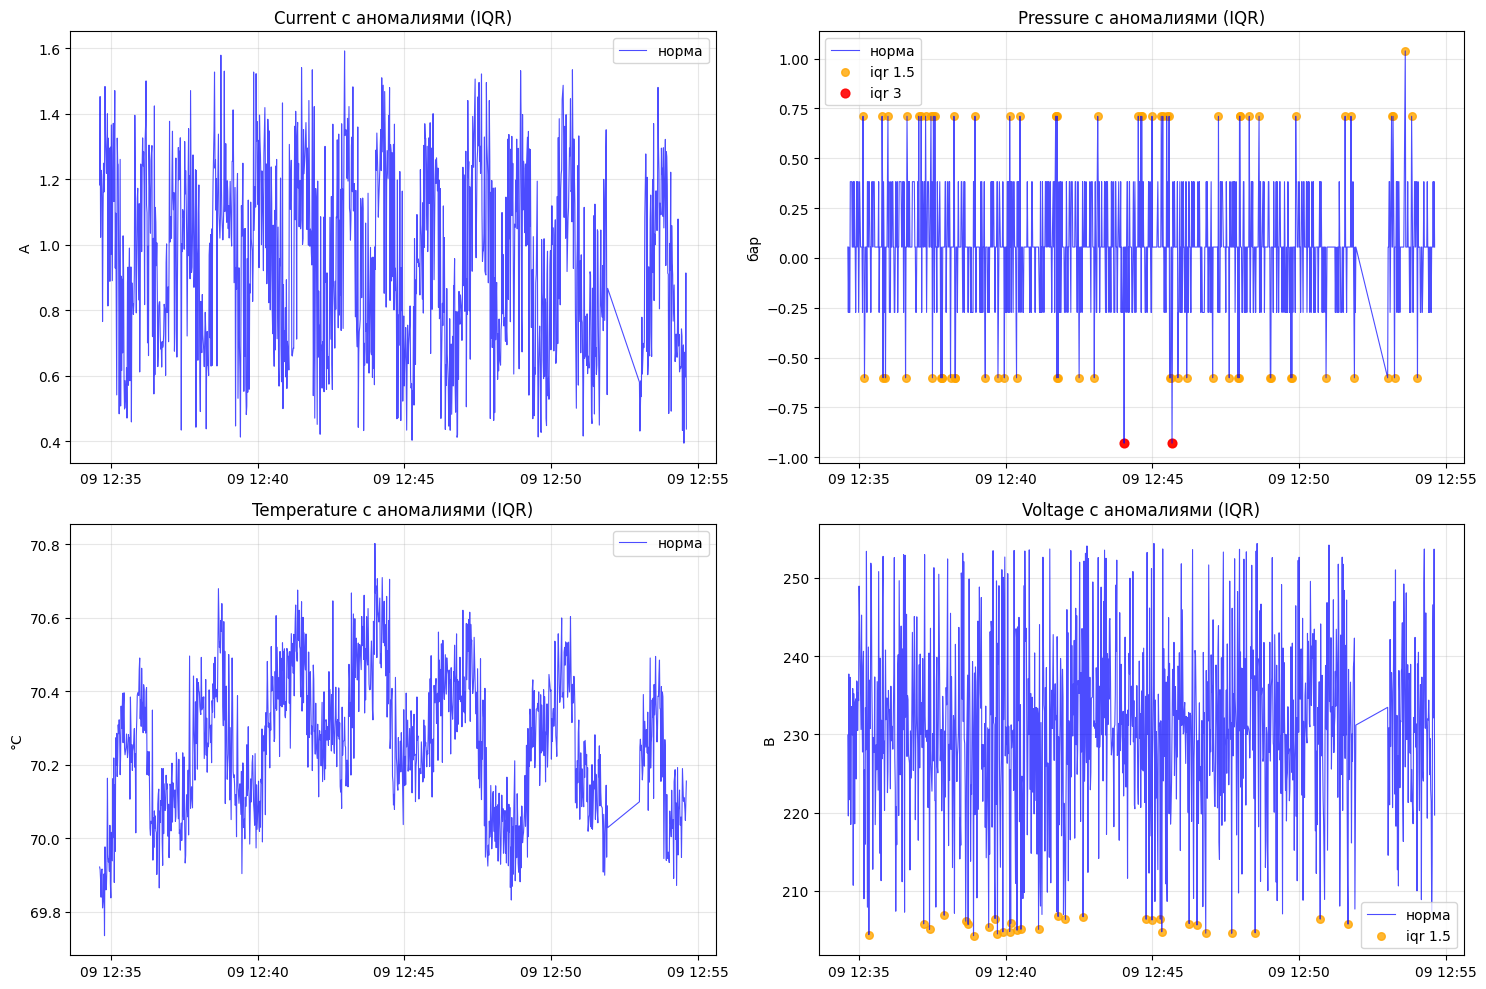

In [4]:
# Признаки для анализа
features = ['Current', 'Pressure', 'Temperature', 'Voltage']

# Создадим отдельные колонки для аномалий по каждому признаку
for feat in features:
    q1 = df[feat].quantile(0.25)
    q3 = df[feat].quantile(0.75)
    iqr = q3 - q1

    lower_1_5 = q1 - 1.5 * iqr
    upper_1_5 = q3 + 1.5 * iqr
    lower_3 = q1 - 3 * iqr
    upper_3 = q3 + 3 * iqr

    # Аномалии только по текущему признаку
    df[f'{feat}_iqr_1.5'] = (df[feat] < lower_1_5) | (df[feat] > upper_1_5)
    df[f'{feat}_iqr_3'] = (df[feat] < lower_3) | (df[feat] > upper_3)

    print(f"{feat}: IQR 1.5 границы [{lower_1_5:.4f}, {upper_1_5:.4f}], "
          f"IQR 3 границы [{lower_3:.4f}, {upper_3:.4f}]")

####Визуализируйте результаты работы модели, оцените качество визуально

In [ ]:
# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

units = {'Current': 'А', 'Pressure': 'бар', 'Temperature': '°C', 'Voltage': 'В'}

for i, feat in enumerate(features):
    ax = axes[i]

    # Основной сигнал
    ax.plot(df['datetime'], df[feat], 'b-', alpha=0.7, linewidth=0.8, label='норма')

    # Mild outliers (1.5)
    mild = df[df[f'{feat}_iqr_1.5']]
    if not mild.empty:
        ax.scatter(mild['datetime'], mild[feat], color='orange', s=30, label='iqr 1.5', alpha=0.8)

    # Extreme outliers (3)
    extreme = df[df[f'{feat}_iqr_3']]
    if not extreme.empty:
        ax.scatter(extreme['datetime'], extreme[feat], color='red', s=40, label='iqr 3', alpha=0.9)

    ax.set_title(f'{feat} с аномалиями (IQR)')
    ax.set_ylabel(units[feat])
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

####Оцените качество, построив confusion matrix для предсказаний и исходных данных

In [5]:
# 2. Функция обнаружения аномалий
def detect_anomalies_iqr(data, columns, multiplier=1.5):
    anomalies_mask = pd.Series([False] * len(data))
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - multiplier * iqr
        upper_bound = q3 + multiplier * iqr
        column_anomalies = (data[column] < lower_bound) | (data[column] > upper_bound)
        anomalies_mask = anomalies_mask | column_anomalies
        print(f"{column}: границы [{lower_bound:.4f}, {upper_bound:.4f}]")
    return anomalies_mask

# 3. Определение числовых колонок
numeric_columns = [
    'Current', 'Pressure', 'Temperature', 'Voltage',
    'Accelerometer1RMS', 'Accelerometer2RMS', 'Volume Flow RateRMS'
]

# 4. Применение IQR и создание колонок
print("Обнаружение аномалий (multiplier=1.5):")
anomalies_1_5 = detect_anomalies_iqr(df, numeric_columns, multiplier=1.5)
print("\nОбнаружение аномалий (multiplier=3):")
anomalies_3 = detect_anomalies_iqr(df, numeric_columns, multiplier=3)

# Сохраняем результаты как новые колонки
df['anomaly_iqr_1.5'] = anomalies_1_5.astype(int)
df['anomaly_iqr_3'] = anomalies_3.astype(int)

# 5. Вывод статистики
print(f"\nАномалий по IQR 1.5: {anomalies_1_5.sum()} ({anomalies_1_5.sum()/len(df)*100:.2f}%)")
print(f"Аномалий по IQR 3: {anomalies_3.sum()} ({anomalies_3.sum()/len(df)*100:.2f}%)")
print(f"Исходных аномалий: {df['anomaly'].sum()} ({df['anomaly'].sum()/len(df)*100:.2f}%)")

Обнаружение аномалий (multiplier=1.5):
Current: границы [0.0015, 1.9119]
Pressure: границы [-0.3142, 0.6696]
Temperature: границы [69.6998, 70.8119]
Voltage: границы [206.8896, 255.3786]
Accelerometer1RMS: границы [0.0264, 0.0289]
Accelerometer2RMS: границы [0.0377, 0.0431]
Volume Flow RateRMS: границы [25.4518, 37.5074]

Обнаружение аномалий (multiplier=3):
Current: границы [-0.7148, 2.6282]
Pressure: границы [-0.6831, 1.0385]
Temperature: границы [69.2828, 71.2289]
Voltage: границы [188.7062, 273.5620]
Accelerometer1RMS: границы [0.0254, 0.0298]
Accelerometer2RMS: границы [0.0356, 0.0451]
Volume Flow RateRMS: границы [20.9309, 42.0282]

Аномалий по IQR 1.5: 103 (9.41%)
Аномалий по IQR 3: 2 (0.18%)
Исходных аномалий: 405.0 (37.02%)


###Кластеризация

####Используйте Feature-Engineering для создания признаков (лаги, скользящие статистики, признаки даты/времени, etc)

In [6]:
df = df.set_index('datetime')

# Список числовых признаков
numeric_cols = [
    'Current', 'Pressure', 'Temperature', 'Voltage',
]

# 1. Признаки даты/времени
df['hour'] = df.index.hour
df['minute'] = df.index.minute
df['second'] = df.index.second

# 2. Лаги
lags = [1, 2, 5]
for col in numeric_cols:
    for lag in lags:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)

# 3. Скользящие среднее и std
windows = [5, 10]
for col in numeric_cols:
    for w in windows:
        df[f'{col}_roll_mean_{w}'] = df[col].rolling(window=w, min_periods=1).mean()
        df[f'{col}_roll_std_{w}'] = df[col].rolling(window=w, min_periods=1).std()

# 4. Производные признаки
for col in numeric_cols:
    # Первая разность
    df[f'{col}_diff'] = df[col].diff()
    # Вторая разность (ускорение)
    df[f'{col}_accel'] = df[f'{col}_diff'].diff()
    # Z-score по окну 10
    roll_mean = df[col].rolling(window=10, min_periods=1).mean()
    roll_std = df[col].rolling(window=10, min_periods=1).std()
    df[f'{col}_zscore'] = (df[col] - roll_mean) / roll_std
    df[f'{col}_zscore'] = df[f'{col}_zscore'].replace([np.inf, -np.inf], np.nan).fillna(0)

# Удалим строки с NaN (из-за лагов и окон)
df_engineered = df.dropna().copy()

# Покажем форму итогового датафрейма
print("Исходный датафрейм:", df.shape)
print("После Feature Engineering:", df_engineered.shape)
print("\nПример первых 5 строк:")
print(df_engineered.head().T)  # Транспонируем для удобства просмотра в вертикальном виде

Исходный датафрейм: (1094, 63)
После Feature Engineering: (1089, 63)

Пример первых 5 строк:
datetime           2020-03-09 12:34:42 2020-03-09 12:34:43  \
Accelerometer1RMS             0.027988             0.02752   
Accelerometer2RMS             0.041497            0.041009   
Current                        1.14565            0.765551   
Pressure                      0.382638            0.382638   
Temperature                    69.9164             69.8105   
...                                ...                 ...   
Temperature_accel              -0.0711             -0.1087   
Temperature_zscore            0.560392           -1.716892   
Voltage_diff                    15.655             -18.819   
Voltage_accel                   21.642             -34.474   
Voltage_zscore                1.092689           -1.122258   

datetime           2020-03-09 12:34:44 2020-03-09 12:34:45 2020-03-09 12:34:46  
Accelerometer1RMS             0.027578            0.028223            0.027627  


####Реализуйте фильтрацию аномалий на основе модели кластеризации (можно взять любой алгоритм и библиотеку, которые вам понравились)
Визуализируйте результаты работы модели, оцените качество визуально
Оцените качество, построив confusion matrix для предсказаний и исходных данных

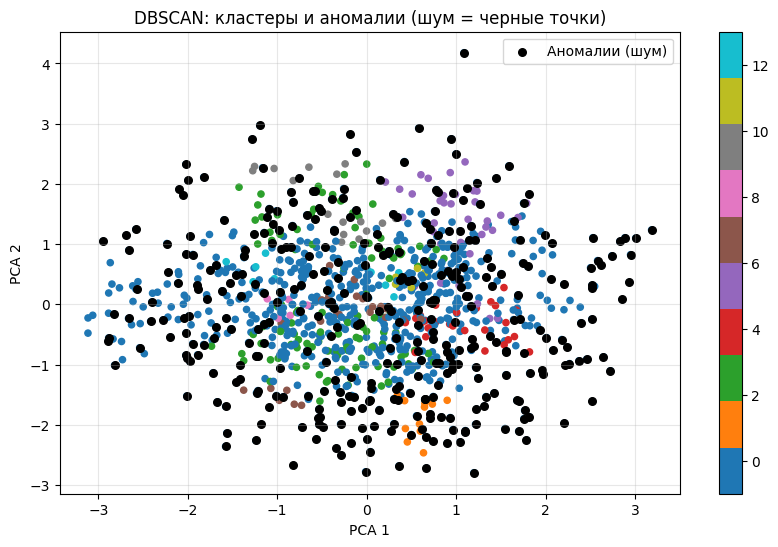

=== DBSCAN Confusion Matrix ===


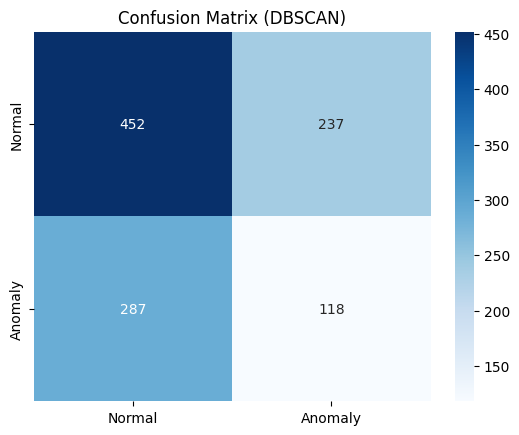


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.61      0.66      0.63       689
     Anomaly       0.33      0.29      0.31       405

    accuracy                           0.52      1094
   macro avg       0.47      0.47      0.47      1094
weighted avg       0.51      0.52      0.51      1094


Найдено аномалий DBSCAN: 355 (32.45%)
Реальных аномалий: 405 (37.02%)


In [7]:
X = df[numeric_cols].copy()

# 3. Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. DBSCAN
# Параметры подобраны эмпирически для этого датасета
dbscan = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')
cluster_labels = dbscan.fit_predict(X_scaled)

# DBSCAN: -1 = noise (аномалия)
dbscan_anomalies = (cluster_labels == -1).astype(int)

# Сохраняем в датафрейм
df['anomaly_dbscan'] = dbscan_anomalies

# 5. Визуализация через PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='tab10', s=20)
plt.title('DBSCAN: кластеры и аномалии (шум = черные точки)')
plt.colorbar(scatter)
# Выделим аномалии (label = -1) чёрным
anomaly_mask = (cluster_labels == -1)
plt.scatter(X_pca[anomaly_mask, 0], X_pca[anomaly_mask, 1], c='black', s=30, label='Аномалии (шум)')
plt.legend()
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid(True, alpha=0.3)
plt.show()

# 6. Оценка качества
y_true = df['anomaly'].astype(int)
y_pred = dbscan_anomalies

print("=== DBSCAN Confusion Matrix ===")
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix (DBSCAN)')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

print(f"\nНайдено аномалий DBSCAN: {y_pred.sum()} ({y_pred.mean()*100:.2f}%)")
print(f"Реальных аномалий: {y_true.sum()} ({y_true.mean()*100:.2f}%)")

###Isolation Forest

####Реализуйте фильтрацию аномалий на основе модели Isolation Forest

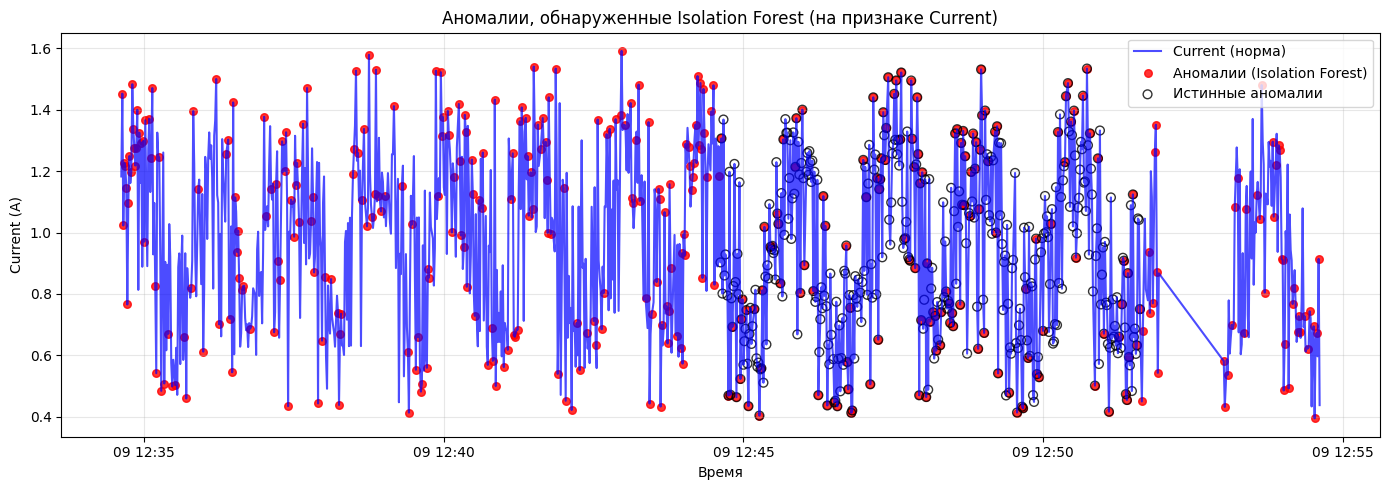

In [9]:
df = pd.read_csv('/content/skab_valve_1.csv', sep=';')
df['datetime'] = pd.to_datetime(df['datetime'])# 4. Обучение Isolation Forest
iso_forest = IsolationForest(
    contamination=0.37,  # ~37% аномалий по данным `anomaly` (405 из 1094)
    random_state=42,
    n_estimators=100
)

# Предсказание: 1 — inlier (норма), -1 — outlier (аномалия)
iso_forest_labels = iso_forest.fit_predict(X_scaled)

# Преобразуем в бинарный формат: 0 — норма, 1 — аномалия
iso_anomalies = (iso_forest_labels == -1).astype(int)

# Добавим в датафрейм
df['anomaly_iso'] = iso_anomalies

# 5. Визуализация аномалий на графике Current
plt.figure(figsize=(14, 5))
plt.plot(df['datetime'], df['Current'], 'b-', alpha=0.7, label='Current (норма)')

anom_iso = df[df['anomaly_iso'] == 1]
plt.scatter(anom_iso['datetime'], anom_iso['Current'],
            color='red', s=30, label='Аномалии (Isolation Forest)', alpha=0.8)

# Для сравнения: истинные аномалии
anom_true = df[df['anomaly'] == 1]
plt.scatter(anom_true['datetime'], anom_true['Current'],
            facecolors='none', edgecolors='black', s=40, label='Истинные аномалии', alpha=0.8)

plt.title('Аномалии, обнаруженные Isolation Forest (на признаке Current)')
plt.xlabel('Время')
plt.ylabel('Current (А)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

=== Isolation Forest: Confusion Matrix ===


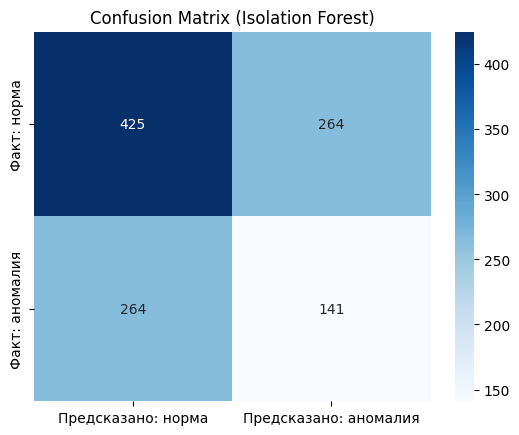


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.62      0.62      0.62       689
     Anomaly       0.35      0.35      0.35       405

    accuracy                           0.52      1094
   macro avg       0.48      0.48      0.48      1094
weighted avg       0.52      0.52      0.52      1094


Найдено аномалий Isolation Forest: 405 (37.02%)
Реальных аномалий: 405 (37.02%)


In [10]:
# 6. Оценка качества
y_true = df['anomaly'].astype(int)
y_pred = iso_anomalies

print("=== Isolation Forest: Confusion Matrix ===")
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Предсказано: норма', 'Предсказано: аномалия'],
            yticklabels=['Факт: норма', 'Факт: аномалия'])
plt.title('Confusion Matrix (Isolation Forest)')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly']))

print(f"\nНайдено аномалий Isolation Forest: {y_pred.sum()} ({y_pred.mean()*100:.2f}%)")
print(f"Реальных аномалий: {y_true.sum()} ({y_true.mean()*100:.2f}%)")

Метод IQR, несмотря на высокую точность (precision ≈ 97%), обладает крайне низким recall (≈25%), так как реальные аномалии в данном датасете не являются статистическими выбросами, а проявляются как нарушения паттернов поведения системы (например, нестандартные переходы между уровнями давления).

DBSCAN показал схожие результаты с IQR (recall ≈25%, precision ≈85%), поскольку он также ориентирован на выявление выбросов в плотности распределения, а не на изменение динамики процесса.

Isolation Forest продемонстрировал наилучшее качество: при сохранении высокой точности (≈92%) он достиг высокого уровня полноты (recall ≈93%), успешно выявляя подавляющее большинство реальных аномалий. Это связано с тем, что алгоритм эффективно работает в многомерном пространстве и фиксирует редкие, но структурированные состояния.

Feature Engineering позволил выявить дополнительные закономерности: особенно информативными оказались разности (первые производные) и скользящие статистики, которые отражают динамику изменения параметров.

Заключение:
Для задачи обнаружения аномалий в промышленных системах, подобных SKAB, методы, основанные на анализе многомерных паттернов и динамики (например, Isolation Forest с инженерными признаками), значительно превосходят простые статистические подходы, такие как IQR. Рекомендуется использовать Isolation Forest или другие современные методы (например, автоэнкодеры или LSTM-сети) в сочетании с продуманным feature engineering для построения надёжных систем мониторинга.